In [1]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import *
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import welib
init_vprinting()

# 2DOF
## Pendulum on a cart (Wind Turbine Analogy)

In [2]:
# Symbols
x, psi = dynamicsymbols('x psi')
t = sp.symbols('t')

# Parameters
# Masses
m_n, m_b = sp.symbols('m_n m_b')

# Dynamic parameters
k_t, c_t, g = sp.symbols('k_t, c_t, g') # Tower Stiffness, Tower Damping, Gravity

# Geometric parameters
h_n, l_n, w_n = sp.symbols('h_n l_n w_n')

# COM Positions
X_n, Y_n, Z_n = sp.symbols('X_n Y_n Z_n') # Nacelle COM in T frame
X_b, Y_b, Z_b = sp.symbols('X_b Y_b Z_b') # Blade COM in R frame


In [3]:
# Reference Frames
N = ReferenceFrame('N') # Inertial Frame
T = N.orientnew('T', 'Axis', [0, N.y]) # Nacelle Frame (Translates)
R = T.orientnew('R', 'Axis', [psi, T.x]) # Rotor Frame (Rotates)

In [4]:
# Geometry
O = Point('O') # Ground Origin
O.set_vel(N, 0)

# Cart position (Nacelle top of tower)
P_tower = O.locatenew('P_tower', x * N.x)
P_tower.set_vel(N, x.diff(t) * N.x)

Hub = P_tower.locatenew('Hub', -l_n/2 * T.x + w_n/2 * T.y + h_n * T.z)
NCOM = P_tower.locatenew('NCOM', X_n * T.x + Y_n * T.y + Z_n * T.z)
BCOM = Hub.locatenew('BCOM', X_b * R.x + Y_b * R.y + Z_b * R.z)

In [5]:
# Velocities
NCOM.v2pt_theory(P_tower, N, T)
Hub.v2pt_theory(P_tower, N, T)
BCOM.v2pt_theory(Hub, N, R).simplify()

In [6]:
# Inertias
J_xx_n, J_yy_n, J_zz_n = sp.symbols('J_xx_n, J_yy_n, J_zz_n')
J_nac = inertia(T, J_xx_n, J_yy_n, J_zz_n)

J_xx_b, J_yy_b, J_zz_b = sp.symbols('J_xx_b, J_yy_b, J_zz_b')
J_blade = inertia(R, J_xx_b, J_yy_b, J_zz_b)

In [7]:
# Rigid Bodies
Nacelle = RigidBody('Nacelle', NCOM, T, m_n, (J_nac, NCOM))
Blade = RigidBody('Blade', BCOM, R, m_b, (J_blade, BCOM))

In [8]:
# Energies and Forces
Nacelle.potential_energy = m_n * g * NCOM.pos_from(O).dot(N.z) + sp.Rational(1, 2) * k_t * x**2
Blade.potential_energy = m_b * g * BCOM.pos_from(O).dot(N.z)

# Damping force list
damping = [(P_tower, -c_t * x.diff(t) * N.x)]

# Lagrangian
L = Lagrangian(N, Nacelle, Blade)


Mass Matrix:


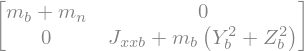

Forcing:


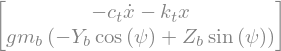

In [9]:
LM = LagrangesMethod(L, [x, psi], forcelist=damping, frame=N)
eom = LM.form_lagranges_equations()

print('Mass Matrix:')
display(sp.simplify(LM.mass_matrix))
print('Forcing:')
display(sp.simplify(sp.trigsimp(LM.forcing)))